
# 2. Correlación cruzada entre Calamar y las otras estaciones

Debido a que las estaciones de Achí y El Banco se encuentran a varios cientos de kilómetros de la estación Calamar, se espera que exista un retardo
temporal entre las variables explicativas y la serie objetivo. Por lo tanto, se realiza inicialmente un análisis de correlación cruzada con el fin 
de identificar el desfase temporal más representativo y desplazar las series de tiempo de las variables explicativas según el lag encontrado, de manera
que se maximice su correlación con la estación de Calamar.

## 2.1. Lectura de archivos de nivel

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Rutas
rutas = {
    "Achi": r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\AchiNivelMedioDiarioCompleto.csv",
    "Calamar": r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\CalamarNivelMedioDiarioCompleto.csv",
    "ElBanco": r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\ElBancoNivelMedioDiarioCompleto.csv"
}

# Lectura
def leer_nivel(ruta, nombre):
    df = pd.read_csv(ruta, parse_dates=["Fecha"])
    df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")
    df["Nivel"] = pd.to_numeric(df["Nivel"], errors="coerce")
    df = df.dropna(subset=["Fecha"]).sort_values("Fecha")

    # Eliminar fechas repetidas
    df = df.drop_duplicates(subset="Fecha", keep="first")

    return df[["Fecha", "Nivel"]].rename(columns={"Nivel": nombre})

# Leer series
series = {nombre: leer_nivel(ruta, nombre) for nombre, ruta in rutas.items()}



## 2.2. Rango de tiempo común entre series

In [20]:

# Tomar intervalo común
fecha_ini = max(df_["Fecha"].min() for df_ in series.values())
fecha_fin = min(df_["Fecha"].max() for df_ in series.values())

print("Fecha inicial común:", fecha_ini)
print("Fecha final común:", fecha_fin)

# Calendario completo dentro del intervalo común
calendario = pd.DataFrame({
    "Fecha": pd.date_range(start=fecha_ini, end=fecha_fin, freq="D")
})

# Unir series al calendario 
df = calendario.copy()
for nombre, dfi in series.items():
    dfi = dfi[(dfi["Fecha"] >= fecha_ini) & (dfi["Fecha"] <= fecha_fin)]
    df = df.merge(dfi, on="Fecha", how="left")

df = df.sort_values("Fecha").reset_index(drop=True)



Fecha inicial común: 1975-06-01 00:00:00
Fecha final común: 2026-02-24 00:00:00


## 2.3. Correlación cruzada

Achi -> Calamar: mejor lag = 16 días, correlación = 0.7313
El Banco -> Calamar: mejor lag = 9 días, correlación = 0.9276


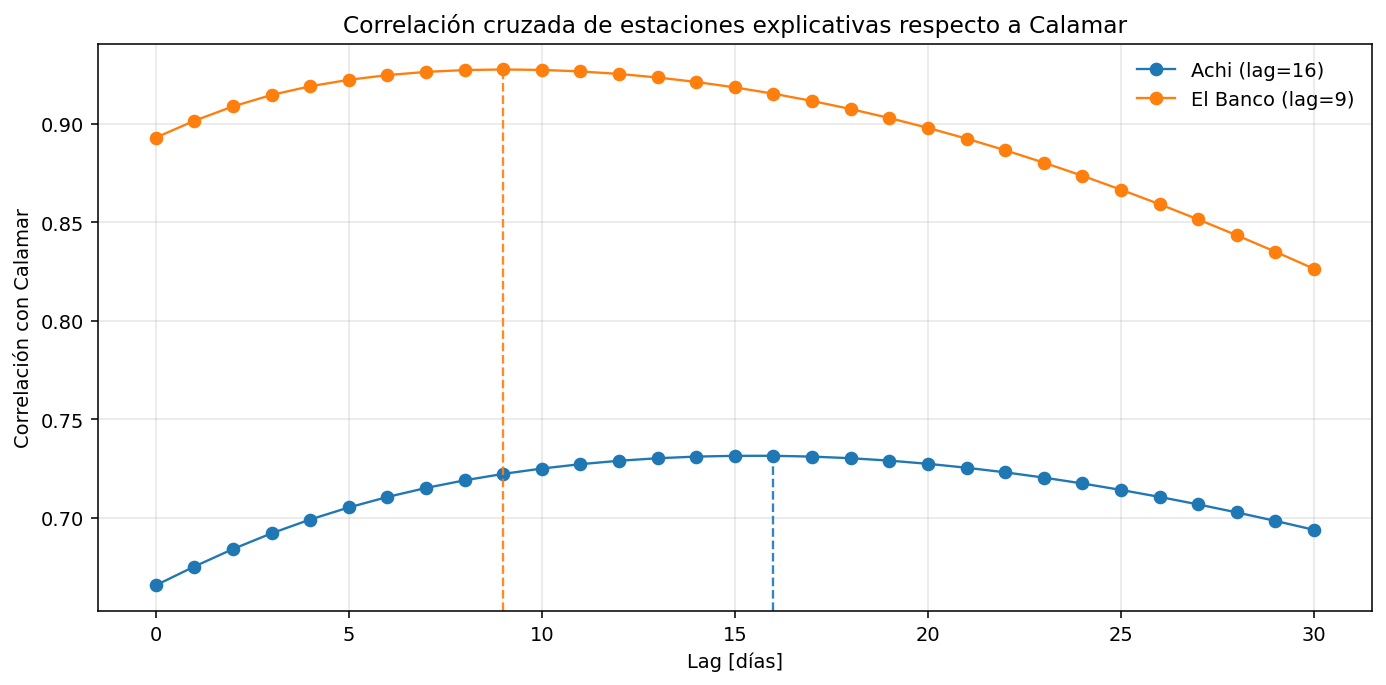

In [21]:

# Correlación cruzada
# lag > 0 significa que la explicativa ocurre antes que Calamar
def correlacion_cruzada(df, explicativa, target="Calamar", max_lag=30):
    resultados = []
    for lag in range(max_lag + 1):
        r = df[explicativa].shift(lag).corr(df[target])
        resultados.append((lag, r))
    out = pd.DataFrame(resultados, columns=["lag_dias", "corr"])
    mejor = out.loc[out["corr"].idxmax()]
    return out, int(mejor["lag_dias"]), float(mejor["corr"])

ccf_achi, lag_achi, corr_achi = correlacion_cruzada(df, "Achi", "Calamar", max_lag=30)
ccf_banco, lag_banco, corr_banco = correlacion_cruzada(df, "ElBanco", "Calamar", max_lag=30)

print(f"Achi -> Calamar: mejor lag = {lag_achi} días, correlación = {corr_achi:.4f}")
print(f"El Banco -> Calamar: mejor lag = {lag_banco} días, correlación = {corr_banco:.4f}")

# Aplicar shifts óptimos
df["Achi_shift"] = df["Achi"].shift(lag_achi)
df["ElBanco_shift"] = df["ElBanco"].shift(lag_banco)

# Recortar NaN de borde causados por el desfase
cols_finales = ["Calamar", "Achi_shift", "ElBanco_shift"]

first_idx = max(df[col].first_valid_index() for col in cols_finales)
last_idx  = min(df[col].last_valid_index()  for col in cols_finales)

df = df.loc[first_idx:last_idx].reset_index(drop=True)

# Gráfica correlación cruzada
fig, ax = plt.subplots(figsize=(10, 5), dpi=140)

l1, = ax.plot(ccf_achi["lag_dias"], ccf_achi["corr"], marker="o", lw=1.2, label=f"Achi (lag={lag_achi})")
l2, = ax.plot(ccf_banco["lag_dias"], ccf_banco["corr"], marker="o", lw=1.2, label=f"El Banco (lag={lag_banco})")

ymin, ymax = ax.get_ylim()

ax.vlines(lag_achi, ymin=ymin, ymax=corr_achi,
          color=l1.get_color(), linestyle="--", linewidth=1.2, alpha=0.9)

ax.vlines(lag_banco, ymin=ymin, ymax=corr_banco,
          color=l2.get_color(), linestyle="--", linewidth=1.2, alpha=0.9)

ax.set_ylim(ymin, ymax)
ax.set_xlabel("Lag [días]")
ax.set_ylabel("Correlación con Calamar")
ax.set_title("Correlación cruzada de estaciones explicativas respecto a Calamar")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# Guardar series finales
df_guardar = df[["Fecha", "Calamar", "Achi", "ElBanco"]].copy()
df_guardar["Fecha"] = df_guardar["Fecha"].dt.strftime("%Y-%m-%d")

df_guardar.to_csv(
    r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\Niveles_alineados.csv",
    index=False
)

Entonces, una vez se conoce el lag representativo, procedemos a realizar el EDA con las series de la estación Achí y El Banco desplazadas.